In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('mymoviedb.csv',lineterminator='\n')

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [5]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


**Exploration summary**
1) there is 9827 rows of data
2) there is nan value and duplicate values
3) overview, movie language and url is of no use in ananlysis so it drop
4) the release date data type is casted into data type for analysis
5) from genre table whitespaces are removed
6) vote average better be catagotize for better analysis

In [8]:
df['Release_date']=pd.to_datetime(df['Release_Date'])
print(df['Release_date'].dtypes)

datetime64[ns]


In [9]:
df['release_date_year']=df['Release_date'].dt.year
df['release_date_year'].dtypes

dtype('int32')

In [10]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Release_date,release_date_year
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021-12-15,2021
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022-03-01,2022
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022-02-25,2022
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021-11-24,2021
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021-12-22,2021


In [11]:
df.drop('Release_Date', axis=1, inplace=True)  # axis=1 means column

In [12]:
df.head()

,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Release_date,release_date_year
0,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021-12-15,2021
1,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022-03-01,2022
2,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022-02-25,2022
3,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021-11-24,2021
4,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021-12-22,2021


dropping unwanted columns

In [14]:
df.drop('Overview', axis=1, inplace=True);  # axis=1 means column
df.drop('Original_Language', axis=1, inplace=True);  # axis=1 means column
df.drop('Poster_Url', axis=1, inplace=True);  # axis=1 means column


In [15]:
df.head()

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_date,release_date_year
0,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",2021-12-15,2021
1,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",2022-03-01,2022
2,No Exit,2618.087,122,6.3,Thriller,2022-02-25,2022
3,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",2021-11-24,2021
4,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",2021-12-22,2021


for better understanding converting Vote_Average column into understandable column means converting the vote number into Popular,average,below_avg and not popular.

In [17]:
def categorize_col(df,col,labels):
    edges=[df[col].describe()['min'],
           df[col].describe()['25%'],
           df[col].describe()['50%'],
           df[col].describe()['75%'],
           df[col].describe()['max']]
    df[col]=pd.cut(df[col],edges,labels=labels,duplicates='drop')
    return df

In [19]:
labels=['not Popular','Below_avg','Average','Popular']

In [20]:
categorize_col(df,'Vote_Average',labels)

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_date,release_date_year
0,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction",2021-12-15,2021
1,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller",2022-03-01,2022
2,No Exit,2618.087,122,Below_avg,Thriller,2022-02-25,2022
3,Encanto,2402.201,5076,Popular,"Animation, Comedy, Family, Fantasy",2021-11-24,2021
4,The King's Man,1895.511,1793,Average,"Action, Adventure, Thriller, War",2021-12-22,2021
...,...,...,...,...,...,...,...
9822,Badlands,13.357,896,Popular,"Drama, Crime",1973-10-15,1973
9823,Violent Delights,13.356,8,not Popular,Horror,2020-10-01,2020
9824,The Offering,13.355,94,not Popular,"Mystery, Thriller, Horror",2016-05-06,2016
9825,The United States vs. Billie Holiday,13.354,152,Average,"Music, Drama, History",2021-03-31,2021


In [21]:
df.head()

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_date,release_date_year
0,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction",2021-12-15,2021
1,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller",2022-03-01,2022
2,No Exit,2618.087,122,Below_avg,Thriller,2022-02-25,2022
3,Encanto,2402.201,5076,Popular,"Animation, Comedy, Family, Fantasy",2021-11-24,2021
4,The King's Man,1895.511,1793,Average,"Action, Adventure, Thriller, War",2021-12-22,2021


In [22]:
df['Vote_Average'].value_counts()

Vote_Average
not Popular    2467
Popular        2450
Average        2412
Below_avg      2398
Name: count, dtype: int64

In [23]:
df.isna().sum()

Title                  0
Popularity             0
Vote_Count             0
Vote_Average         100
Genre                  0
Release_date           0
release_date_year      0
dtype: int64

In [24]:
df.dropna(inplace=True)

In [25]:
df.isna().sum()

Title                0
Popularity           0
Vote_Count           0
Vote_Average         0
Genre                0
Release_date         0
release_date_year    0
dtype: int64

In [26]:
df['Genre']=df['Genre'].str.split(', ')

In [27]:
df=df.explode('Genre').reset_index(drop=True)

In [28]:
df.head()

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_date,release_date_year
0,Spider-Man: No Way Home,5083.954,8940,Popular,Action,2021-12-15,2021
1,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure,2021-12-15,2021
2,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction,2021-12-15,2021
3,The Batman,3827.658,1151,Popular,Crime,2022-03-01,2022
4,The Batman,3827.658,1151,Popular,Mystery,2022-03-01,2022


explode(column name) is use to break the list into different rows as above I converted the genre each row collection into a list then from explode function I broke the list

In [29]:
#casting the genre column into a column and it is done with the help of istype
df['Genre']=df['Genre'].astype('category')

In [30]:
df.head()

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_date,release_date_year
0,Spider-Man: No Way Home,5083.954,8940,Popular,Action,2021-12-15,2021
1,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure,2021-12-15,2021
2,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction,2021-12-15,2021
3,The Batman,3827.658,1151,Popular,Crime,2022-03-01,2022
4,The Batman,3827.658,1151,Popular,Mystery,2022-03-01,2022


In [31]:
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Title              25552 non-null  object        
 1   Popularity         25552 non-null  float64       
 2   Vote_Count         25552 non-null  int64         
 3   Vote_Average       25552 non-null  category      
 4   Genre              25552 non-null  category      
 5   Release_date       25552 non-null  datetime64[ns]
 6   release_date_year  25552 non-null  int32         
dtypes: category(2), datetime64[ns](1), float64(1), int32(1), int64(1), object(1)
memory usage: 949.2+ KB


In [33]:
df.nunique()

Title                9415
Popularity           8088
Vote_Count           3265
Vote_Average            4
Genre                  19
Release_date         5846
release_date_year     100
dtype: int64

# VISUALIZATION

In [34]:
sns.set_style('whitegrid')
plt.show()

# most released genre

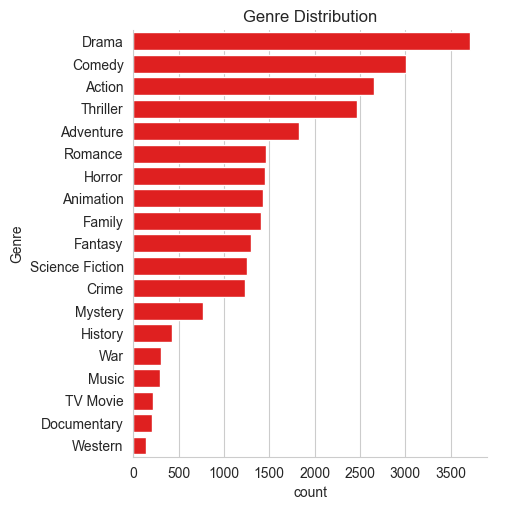

In [35]:
sns.catplot(y='Genre',data=df,kind='count',order=df['Genre'].value_counts().index,color='#FF0000')
plt.title('Genre Distribution')
plt.show()

# Which has the highest vote in vote avg column

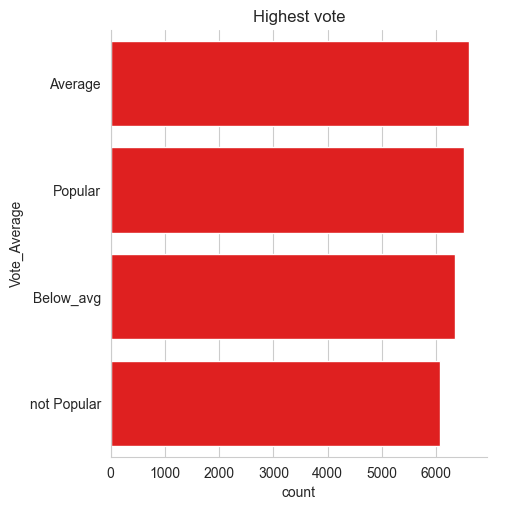

In [36]:
sns.catplot(y='Vote_Average',data=df,kind='count',order=df['Vote_Average'].value_counts().index,color='#FF0000')
plt.title('Highest vote')
plt.show()

# MOVIE WITH HIGHEST POPULARITY AND ITS GENRE

In [39]:
df[df['Popularity']==df['Popularity'].max()]

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_date,release_date_year
0,Spider-Man: No Way Home,5083.954,8940,Popular,Action,2021-12-15,2021
1,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure,2021-12-15,2021
2,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction,2021-12-15,2021


# MOVIE WITH LOWEST POPULARITY AND ITS GENRE

In [40]:
df[df['Popularity']==df['Popularity'].min()]

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_date,release_date_year
25546,The United States vs. Billie Holiday,13.354,152,Average,Music,2021-03-31,2021
25547,The United States vs. Billie Holiday,13.354,152,Average,Drama,2021-03-31,2021
25548,The United States vs. Billie Holiday,13.354,152,Average,History,2021-03-31,2021
25549,Threads,13.354,186,Popular,War,1984-09-23,1984
25550,Threads,13.354,186,Popular,Drama,1984-09-23,1984
25551,Threads,13.354,186,Popular,Science Fiction,1984-09-23,1984


# WHICH YEAR GO MOST MOVIE RELEASED

In [41]:
plt.figure(figsize=(12,16))

<Figure size 1200x1600 with 0 Axes>

<Figure size 1200x1600 with 0 Axes>

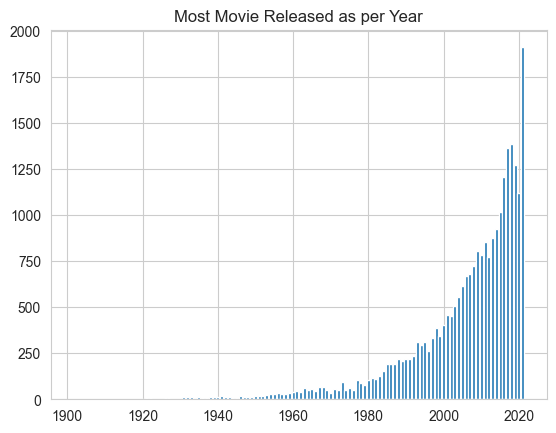

In [43]:
plt.hist(df['release_date_year'],bins=range(1902,2023),align='left',rwidth=0.8)
plt.title("Most Movie Released as per Year")
plt.show()

# Information Extracted
1) Most released genre is Drama.
2) Average movies has highest votes.
3) Spider-Man:No way Home is the most popular movie.
4) The United States vs. Billie Holiday is the least popular movie.
5) The number of movies released per year has grown significantly over time, with a sharp increase after 2000.